# 03 - Exploratory Data Analysis: LUNA 16 CSVs

Before loading CT scans, we analyze the CSV files to understand:
- `candidates.csv`: All candidate nodule locations (551k entries)
- `annotations.csv`: Confirmed nodules with diameter info (1.2k entries)

This gives us a roadmap for what to look for in the CT volumes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configure plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [2]:
# Paths
LUNA_DIR = Path("../data/luna")

# Load CSVs
candidates_df = pd.read_csv(LUNA_DIR / "candidates.csv")
annotations_df = pd.read_csv(LUNA_DIR / "annotations.csv")

print(f"Candidates: {len(candidates_df):,} rows")
print(f"Annotations: {len(annotations_df):,} rows")

Candidates: 551,065 rows
Annotations: 1,186 rows


## 1. Basic Structure

In [3]:
print("=" * 60)
print("CANDIDATES.CSV")
print("=" * 60)
print(f"Shape: {candidates_df.shape}")
print(f"\nColumns: {list(candidates_df.columns)}")
print(f"\nData types:\n{candidates_df.dtypes}")
print(f"\nMissing values:\n{candidates_df.isnull().sum()}")
candidates_df.head()

CANDIDATES.CSV
Shape: (551065, 5)

Columns: ['seriesuid', 'coordX', 'coordY', 'coordZ', 'class']

Data types:
seriesuid        str
coordX       float64
coordY       float64
coordZ       float64
class          int64
dtype: object

Missing values:
seriesuid    0
coordX       0
coordY       0
coordZ       0
class        0
dtype: int64


,seriesuid,coordX,coordY,coordZ,class
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-56.08,-67.85,-311.92,0
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,53.21,-244.41,-245.17,0
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.66,-121.80,-286.62,0
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-33.66,-72.75,-308.41,0
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-32.25,-85.36,-362.51,0


In [4]:
print("=" * 60)
print("ANNOTATIONS.CSV")
print("=" * 60)
print(f"Shape: {annotations_df.shape}")
print(f"\nColumns: {list(annotations_df.columns)}")
print(f"\nData types:\n{annotations_df.dtypes}")
print(f"\nMissing values:\n{annotations_df.isnull().sum()}")
annotations_df.head()

ANNOTATIONS.CSV
Shape: (1186, 5)

Columns: ['seriesuid', 'coordX', 'coordY', 'coordZ', 'diameter_mm']

Data types:
seriesuid          str
coordX         float64
coordY         float64
coordZ         float64
diameter_mm    float64
dtype: object

Missing values:
seriesuid      0
coordX         0
coordY         0
coordZ         0
diameter_mm    0
dtype: int64


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


## 2. Candidates Analysis

In [5]:
# Class distribution (0 = non-nodule, 1 = nodule)
class_counts = candidates_df['class'].value_counts().sort_index()
print("Class Distribution:")
print(f"  Non-nodules (0): {class_counts[0]:,} ({class_counts[0]/len(candidates_df)*100:.2f}%)")
print(f"  Nodules (1):     {class_counts[1]:,} ({class_counts[1]/len(candidates_df)*100:.2f}%)")
print(f"\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")

Class Distribution:
  Non-nodules (0): 549,714 (99.75%)
  Nodules (1):     1,351 (0.25%)

Imbalance ratio: 406.9:1


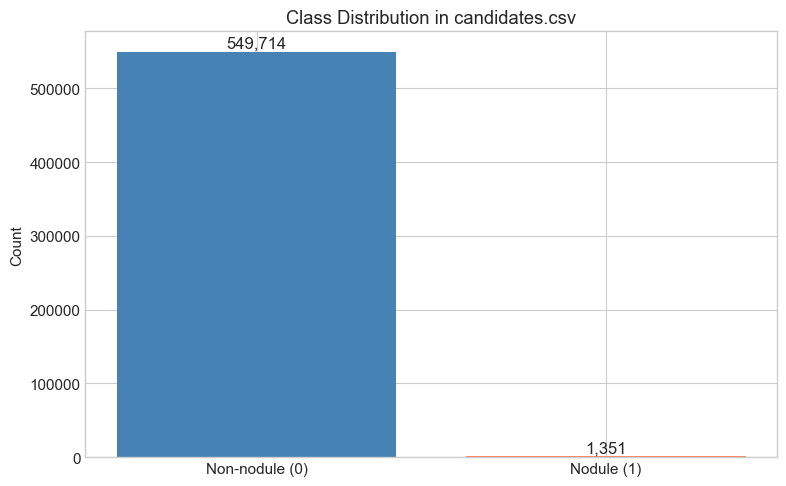

In [6]:
# Visualize class imbalance
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Non-nodule (0)', 'Nodule (1)'], class_counts.values, 
              color=['steelblue', 'coral'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution in candidates.csv')

# Add value labels
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, 
            f'{count:,}', ha='center', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
# Candidates per CT scan
candidates_per_scan = candidates_df.groupby('seriesuid').size()

print("Candidates per CT scan:")
print(f"  Min:    {candidates_per_scan.min()}")
print(f"  Max:    {candidates_per_scan.max()}")
print(f"  Mean:   {candidates_per_scan.mean():.1f}")
print(f"  Median: {candidates_per_scan.median():.1f}")
print(f"\nUnique CT scans: {candidates_df['seriesuid'].nunique()}")

Candidates per CT scan:
  Min:    32
  Max:    1468
  Mean:   620.6
  Median: 582.5

Unique CT scans: 888


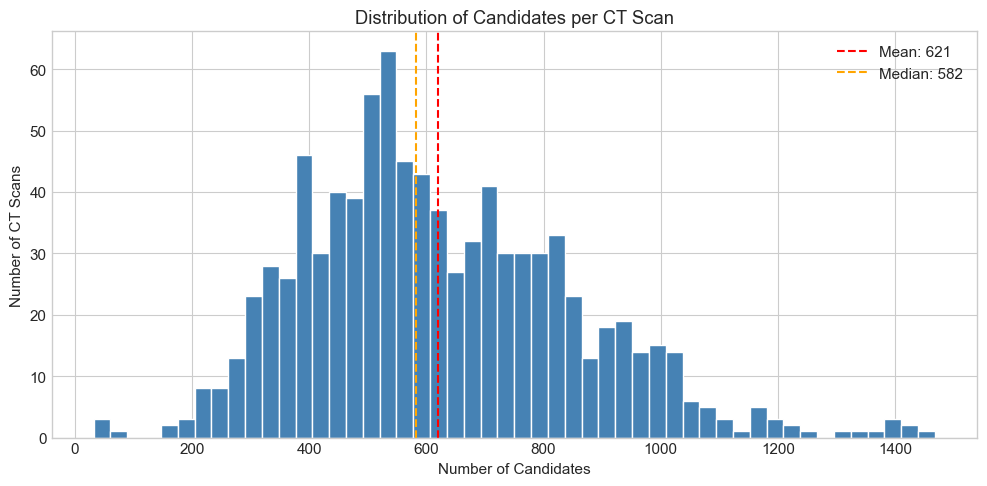

In [8]:
# Distribution of candidates per scan
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(candidates_per_scan, bins=50, color='steelblue', edgecolor='white')
ax.axvline(candidates_per_scan.mean(), color='red', linestyle='--', label=f'Mean: {candidates_per_scan.mean():.0f}')
ax.axvline(candidates_per_scan.median(), color='orange', linestyle='--', label=f'Median: {candidates_per_scan.median():.0f}')
ax.set_xlabel('Number of Candidates')
ax.set_ylabel('Number of CT Scans')
ax.set_title('Distribution of Candidates per CT Scan')
ax.legend()
plt.tight_layout()
plt.show()

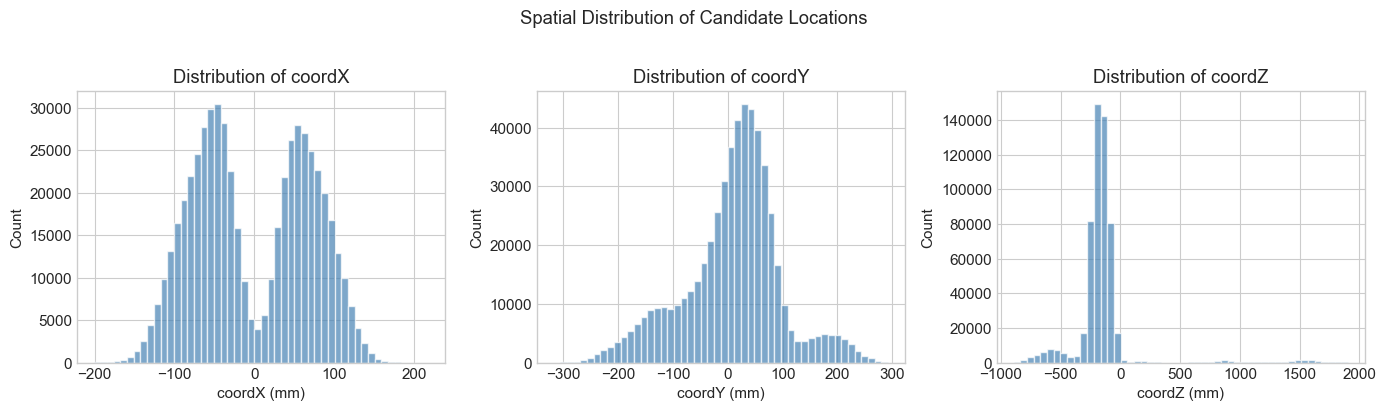

In [9]:
# Spatial distribution of candidates
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, coord in zip(axes, ['coordX', 'coordY', 'coordZ']):
    ax.hist(candidates_df[coord], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_xlabel(f'{coord} (mm)')
    ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {coord}')

plt.suptitle('Spatial Distribution of Candidate Locations', y=1.02)
plt.tight_layout()
plt.show()

## 3. Annotations Analysis

In [10]:
# Nodule diameter statistics
print("Nodule Diameter (mm) Statistics:")
print(annotations_df['diameter_mm'].describe())

Nodule Diameter (mm) Statistics:
count    1186.000000
mean        8.306527
std         4.762033
min         3.253443
25%         5.107177
50%         6.433600
75%         9.696301
max        32.270030
Name: diameter_mm, dtype: float64


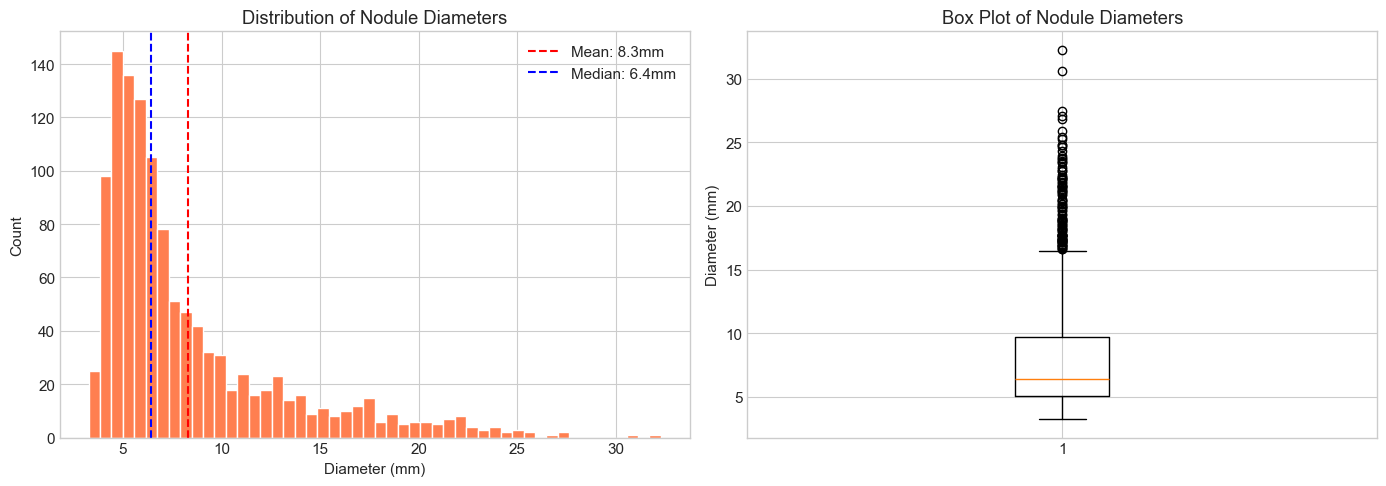

In [11]:
# Diameter distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(annotations_df['diameter_mm'], bins=50, color='coral', edgecolor='white')
axes[0].axvline(annotations_df['diameter_mm'].mean(), color='red', linestyle='--', 
                label=f"Mean: {annotations_df['diameter_mm'].mean():.1f}mm")
axes[0].axvline(annotations_df['diameter_mm'].median(), color='blue', linestyle='--',
                label=f"Median: {annotations_df['diameter_mm'].median():.1f}mm")
axes[0].set_xlabel('Diameter (mm)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Nodule Diameters')
axes[0].legend()

# Box plot
axes[1].boxplot(annotations_df['diameter_mm'], vert=True)
axes[1].set_ylabel('Diameter (mm)')
axes[1].set_title('Box Plot of Nodule Diameters')

plt.tight_layout()
plt.show()

In [12]:
# Nodules per CT scan
nodules_per_scan = annotations_df.groupby('seriesuid').size()

print("Nodules per CT scan:")
print(f"  Min:    {nodules_per_scan.min()}")
print(f"  Max:    {nodules_per_scan.max()}")
print(f"  Mean:   {nodules_per_scan.mean():.2f}")
print(f"\nScans with nodules: {annotations_df['seriesuid'].nunique()}")
print(f"\nDistribution:")
print(nodules_per_scan.value_counts().sort_index())

Nodules per CT scan:
  Min:    1
  Max:    12
  Mean:   1.97

Scans with nodules: 601

Distribution:
1     310
2     159
3      63
4      24
5      23
6      11
7       4
8       2
9       4
12      1
Name: count, dtype: int64


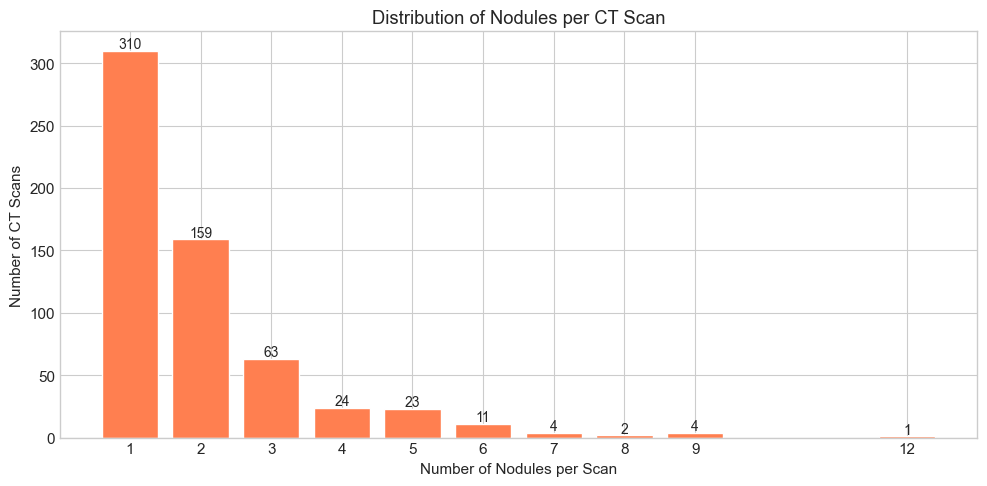

In [13]:
# Bar plot of nodules per scan
nodule_counts = nodules_per_scan.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(nodule_counts.index, nodule_counts.values, color='coral', edgecolor='white')
ax.set_xlabel('Number of Nodules per Scan')
ax.set_ylabel('Number of CT Scans')
ax.set_title('Distribution of Nodules per CT Scan')
ax.set_xticks(nodule_counts.index)

# Add value labels
for bar, count in zip(bars, nodule_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Cross-Reference Analysis

In [14]:
# Compare series_uid between files
candidates_series = set(candidates_df['seriesuid'].unique())
annotations_series = set(annotations_df['seriesuid'].unique())

print("Series UID Comparison:")
print(f"  Unique series in candidates.csv: {len(candidates_series)}")
print(f"  Unique series in annotations.csv: {len(annotations_series)}")
print(f"  Series in both: {len(candidates_series & annotations_series)}")
print(f"  Series only in candidates: {len(candidates_series - annotations_series)}")
print(f"  Series only in annotations: {len(annotations_series - candidates_series)}")

Series UID Comparison:
  Unique series in candidates.csv: 888
  Unique series in annotations.csv: 601
  Series in both: 601
  Series only in candidates: 287
  Series only in annotations: 0


In [15]:
# Positive candidates vs annotations
positive_candidates = candidates_df[candidates_df['class'] == 1]

print(f"Positive candidates (class=1): {len(positive_candidates)}")
print(f"Annotations: {len(annotations_df)}")
print(f"\nNote: These may not match exactly because candidates are")
print(f"      detected points, while annotations are expert-marked nodules.")

Positive candidates (class=1): 1351
Annotations: 1186

Note: These may not match exactly because candidates are
      detected points, while annotations are expert-marked nodules.


## 5. Key Insights Summary

In [16]:
print("=" * 60)
print("KEY INSIGHTS")
print("=" * 60)
print(f"""
DATASET OVERVIEW:
- Total CT scans: {len(candidates_series)}
- Scans with confirmed nodules: {len(annotations_series)}

CANDIDATES (candidates.csv):
- Total candidates: {len(candidates_df):,}
- Positive (nodules): {class_counts[1]:,} ({class_counts[1]/len(candidates_df)*100:.2f}%)
- Negative (non-nodules): {class_counts[0]:,} ({class_counts[0]/len(candidates_df)*100:.2f}%)
- Class imbalance: {class_counts[0]/class_counts[1]:.0f}:1
- Avg candidates per scan: {candidates_per_scan.mean():.0f}

NODULES (annotations.csv):
- Confirmed nodules: {len(annotations_df):,}
- Diameter range: {annotations_df['diameter_mm'].min():.1f}mm - {annotations_df['diameter_mm'].max():.1f}mm
- Mean diameter: {annotations_df['diameter_mm'].mean():.1f}mm
- Median diameter: {annotations_df['diameter_mm'].median():.1f}mm
- Avg nodules per positive scan: {nodules_per_scan.mean():.2f}

IMPLICATIONS FOR MODELING:
1. Severe class imbalance - need weighted loss or sampling strategies
2. Variable nodule sizes - ensure train/val splits have similar distributions
3. Some scans have multiple nodules - consider per-scan aggregation for diagnosis
""")

KEY INSIGHTS

DATASET OVERVIEW:
- Total CT scans: 888
- Scans with confirmed nodules: 601

CANDIDATES (candidates.csv):
- Total candidates: 551,065
- Positive (nodules): 1,351 (0.25%)
- Negative (non-nodules): 549,714 (99.75%)
- Class imbalance: 407:1
- Avg candidates per scan: 621

NODULES (annotations.csv):
- Confirmed nodules: 1,186
- Diameter range: 3.3mm - 32.3mm
- Mean diameter: 8.3mm
- Median diameter: 6.4mm
- Avg nodules per positive scan: 1.97

IMPLICATIONS FOR MODELING:
1. Severe class imbalance - need weighted loss or sampling strategies
2. Variable nodule sizes - ensure train/val splits have similar distributions
3. Some scans have multiple nodules - consider per-scan aggregation for diagnosis



## Next Steps

With this understanding of the CSV data, we can now:
1. Load CT scan volumes (.mhd/.raw files)
2. Map coordinates from CSVs to voxel positions in CT volumes
3. Extract nodule patches for the classification model